# Data Exploration - Vietnamese News Summarization

Notebook này thực hiện:
1. Load dataset (HuggingFace format)
2. Visualize data distribution
3. Explore sample examples
4. Test preprocessing pipeline
5. Understand PhoBERT vs ViT5 formats

---

## ⚠️ Important Notes:

### Dataset Format:
- **Source**: HuggingFace datasets (`data/raw/partial_dataset/`)
- **Keys**: `guid`, `title`, `abstract`, `article`
- **Text**: Already word-segmented (có underscore: `Cơ_quan`, `Cảnh_sát`)

### Model Requirements:
- **PhoBERT** (extractive): Needs text **WITH** underscores
- **ViT5** (abstractive): Needs text **WITHOUT** underscores

### Preprocessor:
- **Default**: underthesea (recommended)
- **Optional**: VnCoreNLP (only for raw text, not pre-tokenized text)


In [1]:
!cd C:\STUDY\code\text_summarization_project

In [2]:
import sys
import os

# Add src to path
sys.path.append('../src')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import from src
from data_loader import VietNewsDataset
from preprocessor import VietnamesePreprocessor

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries loaded successfully!")
print(f"Working directory: {os.getcwd()}")


Libraries loaded successfully!
Working directory: c:\STUDY\code\text_summarization_project\notebooks


## 1. Load Dataset

**Dataset location**: `text_summarization_project/data/raw/`

Available datasets:
- `partial_dataset` - 1,400 samples (1,000 train / 200 val / 200 test)
- `full_dataset` - Full dataset (if available)

**Format**: HuggingFace datasets
- Keys: `guid`, `title`, `abstract`, `article`
- All text is **already word-segmented** (has underscores)
- Pre-split into train/validation/test


In [3]:
# Initialize dataset loader (auto-detects project root)
dataset = VietNewsDataset()

print(f"Data directory: {dataset.data_dir}")
print(f"Raw directory: {dataset.raw_dir}")

# Load dataset
# Available datasets: 'partial_dataset' or 'full_dataset'
try:
    dataset.load_raw('partial_dataset')
    print(f"\n✅ Dataset loaded successfully!")
    print(f"  Train: {len(dataset.train_data)} samples")
    print(f"  Validation: {len(dataset.val_data)} samples")
    print(f"  Test: {len(dataset.test_data)} samples")
except FileNotFoundError as e:
    print(f"\n❌ Error loading dataset: {e}")
    print("\nMake sure dataset exists at:")
    print("  text_summarization_project/data/raw/partial_dataset/")


Data directory: c:\STUDY\code\text_summarization_project\data
Raw directory: c:\STUDY\code\text_summarization_project\data\raw
Loaded dataset from partial_dataset:
  Train: 1000 samples
  Validation: 200 samples
  Test: 200 samples

✅ Dataset loaded successfully!
  Train: 1000 samples
  Validation: 200 samples
  Test: 200 samples


## 2. Basic Statistics


In [4]:
# Get statistics for each split
print("="*70)
print("DATASET STATISTICS")
print("="*70)

for split_name in ['train', 'val', 'test']:
    stats = dataset.get_statistics(split=split_name)
    
    print(f"\n{split_name.upper()} SET:")
    print(f"  Total samples: {stats['total_samples']}")
    print(f"  Avg article length: {stats['avg_article_length']:.1f} words")
    print(f"  Avg abstract length: {stats['avg_abstract_length']:.1f} words")
    print(f"  Avg compression ratio: {stats['avg_compression_ratio']:.2%}")

print("="*70)


DATASET STATISTICS

TRAIN SET:
  Total samples: 1000
  Avg article length: 406.3 words
  Avg abstract length: 32.7 words
  Avg compression ratio: 9.33%

VAL SET:
  Total samples: 200
  Avg article length: 411.2 words
  Avg abstract length: 33.1 words
  Avg compression ratio: 9.57%

TEST SET:
  Total samples: 200
  Avg article length: 405.1 words
  Avg abstract length: 33.4 words
  Avg compression ratio: 9.70%


## 3. Data Distribution Visualization


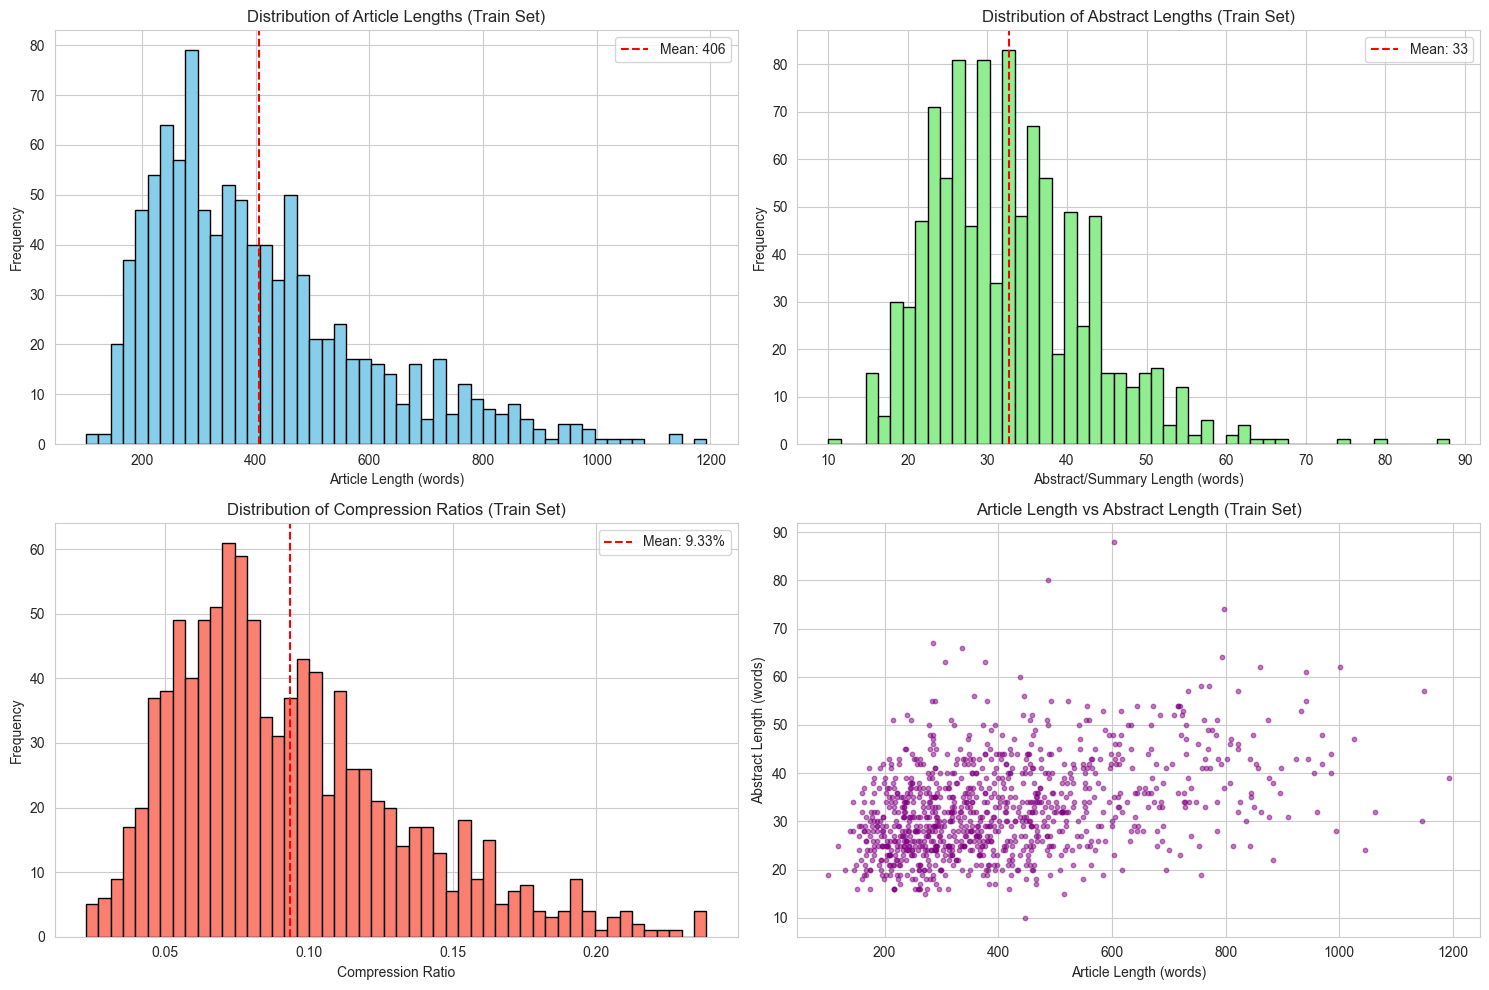


Visualized 1000 samples from train set


In [5]:
# Get statistics for visualization (using train set)
stats = dataset.get_statistics(split='train')

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Article length distribution
axes[0, 0].hist(stats['article_lengths'], bins=50, color='skyblue', edgecolor='black')
axes[0, 0].axvline(stats['avg_article_length'], color='red', linestyle='--', 
                   label=f'Mean: {stats["avg_article_length"]:.0f}')
axes[0, 0].set_xlabel('Article Length (words)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Article Lengths (Train Set)')
axes[0, 0].legend()

# Abstract length distribution
axes[0, 1].hist(stats['abstract_lengths'], bins=50, color='lightgreen', edgecolor='black')
axes[0, 1].axvline(stats['avg_abstract_length'], color='red', linestyle='--',
                   label=f'Mean: {stats["avg_abstract_length"]:.0f}')
axes[0, 1].set_xlabel('Abstract/Summary Length (words)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Abstract Lengths (Train Set)')
axes[0, 1].legend()

# Compression ratio distribution
axes[1, 0].hist(stats['compression_ratios'], bins=50, color='salmon', edgecolor='black')
axes[1, 0].axvline(stats['avg_compression_ratio'], color='red', linestyle='--',
                   label=f'Mean: {stats["avg_compression_ratio"]:.2%}')
axes[1, 0].set_xlabel('Compression Ratio')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Compression Ratios (Train Set)')
axes[1, 0].legend()

# Scatter: Article vs Abstract length
axes[1, 1].scatter(stats['article_lengths'], stats['abstract_lengths'], 
                   alpha=0.5, s=10, color='purple')
axes[1, 1].set_xlabel('Article Length (words)')
axes[1, 1].set_ylabel('Abstract Length (words)')
axes[1, 1].set_title('Article Length vs Abstract Length (Train Set)')

plt.tight_layout()
plt.show()

print(f"\nVisualized {stats['total_samples']} samples from train set")


## 4. Sample Examples


In [6]:
# Display 5 random samples
np.random.seed(42)
sample_indices = np.random.choice(len(dataset.data), 5, replace=False)

for idx in sample_indices:
    sample = dataset.data[idx]
    
    print("\n" + "="*80)
    print(f"SAMPLE {idx}: {sample['id']}")
    print("="*80)
    print(f"\nTitle: {sample['title']}")
    print(f"\nArticle ({len(sample['article'].split())} words):")
    print(sample['article'][:300] + "...")
    print(f"\nSummary ({len(sample['summary'].split())} words):")
    print(sample['summary'])
    print(f"\nCompression: {len(sample['summary'].split()) / len(sample['article'].split()):.2%}")



SAMPLE 1 (Index: 521, GUID: 524)

Title:
  Ông Trần_Bắc_Hà có_thể sẽ phải đối_mặt mức án tới 20 năm tù...

Article (311 words):
  Như báo Người Đưa_Tin đã thông_tin , cơ_quan Cảnh_sát điều_tra ( bộ Công_an ) vừa tống_đạt quyết_định khởi_tố bị_can , khám_xét với ông Trần_Bắc_Hà ( 61 tuổi , cựu Chủ_tịch Hội_đồng_quản_trị BIDV ) , Trần_Lục_Lang ( cựu Phó tổng_giám_đốc ) , Kiều_Đình_Hoà ( cựu Giám_đốc BIDV Hà_Tĩnh ) , Lê_Thị_Vân_A...

Abstract (25 words):
  Bị bắt về tội Vi_phạm quy_định về hoạt_động ngân_hàng , " ông trùm " BIDV Trần_Bắc_Hà sẽ phải đối_mặt mức án 20 năm tù ....

Compression: 8.04%

SAMPLE 2 (Index: 737, GUID: 741)

Title:
  Hoàn_cảnh đáng thương của bé gái tử_vong với vết cứa trên cổ_nghi bị b...

Article (1002 words):
  Sự_việc cháu Nguyễn_Thị_Khánh_N. ( SN 2008 , trú tại xóm Hoàng_Hà , xã Văn_Luông , huyện Tân_Sơn , tỉnh Phú_Thọ ) bất_ngờ tử_vong do bị một nhát dao cứa vào cổ , đứt động_mạch và cổ_họng khiến người_dân ở xóm Hoàng_Hà hết_sức bàng_hoàng và phẫn_nộ . Đa_s

## 5. Test Preprocessing Pipeline


In [7]:
# Initialize preprocessor
preprocessor = VietnamesePreprocessor()

# Test với một sample
test_sample = dataset.data[0]

print("Testing Vietnamese Preprocessor")
print("="*80)
print("\nOriginal article (first 200 chars):")
print(test_sample['article'][:200])

# Normalize
normalized = preprocessor.normalize_text(test_sample['article'])
print("\nNormalized (first 200 chars):")
print(normalized[:200])

# Sentence tokenize
sentences = preprocessor.sentence_tokenize(test_sample['article'])
print(f"\nSentence tokenization: {len(sentences)} sentences")
print("First 3 sentences:")
for i, sent in enumerate(sentences[:3], 1):
    print(f"  {i}. {sent}")

# Word tokenize
tokenized = preprocessor.word_tokenize(test_sample['article'])
print("\nWord tokenized (first 200 chars):")
print(tokenized[:200])

# Full preprocessing
processed = preprocessor.preprocess_document(test_sample['article'])
print("\nFull preprocessing result keys:")
print(f"  {list(processed.keys())}")


TESTING VIETNAMESE PREPROCESSOR

[1] ORIGINAL DATA (from dataset):
  Title: Khởi_tố kẻ_trộm hơn 1 tạ thóc và hơn 8 triệu đồng của chú ruột để lấy tiền mua m...
  Article (first 200 chars): Ngày 27/3 , Cơ_quan Cảnh_sát điều_tra Công_an TP. Hưng_Yên , tỉnh Hưng_Yên cho biết , đơn_vị vừa ra quyết_định khởi_tố vụ án , khởi_tố bị_can đối_với đối_tượng Mai_Văn_Thương ( SN 1989 , trú tại đội 1...
  Abstract: Với bản_tính ham chơi , lười làm , có nhiều tiền_án tiền_sự , lại nghiện ma_tuý , Thương đã đột_nhập...

[2] FULL PREPROCESSING:

  Available keys: ['original', 'tokenized', 'detokenized', 'sentences', 'sentences_tokenized']
  Number of sentences: 9

[3] MODEL-SPECIFIC FORMATS:

  A. For PhoBERT (extractive - WITH underscore):
     Tokenized: Ngày 27/3 , Cơ_quan Cảnh_sát điều_tra Công_an TP. Hưng_Yên , tỉnh Hưng_Yên cho biết , đơn_vị vừa ra quyết_định khởi_tố vụ án , khởi_tố bị_can đối_với ...

  B. For ViT5 (abstractive - NO underscore):
     Detokenized: Ngày 27/3 , Cơ quan Cảnh sát điề

## 6. Train/Val/Test Split


In [8]:
# Split dataset
train_data, val_data, test_data = dataset.train_val_test_split(
    train_ratio=0.8,
    val_ratio=0.1,
    test_ratio=0.1,
    random_state=42
)

print("\nSplit completed:")
print(f"  Train: {len(train_data)} samples")
print(f"  Val:   {len(val_data)} samples")
print(f"  Test:  {len(test_data)} samples")


DATASET SPLITS (Already Pre-Split)

✅ Train set:      1000 samples
✅ Validation set: 200 samples
✅ Test set:       200 samples

Total:            1400 samples

Split ratios:
  Train:      71.4%
  Validation: 14.3%
  Test:       14.3%



In [9]:
# Save splits
dataset.save_splits()
print("Splits saved successfully!")


✅ Splits are already saved in HuggingFace datasets format
   Located at: data/raw/partial_dataset/

   Structure:
   ├── train/
   ├── validation/
   └── test/


## 7. Preprocess Dataset (Optional)

Preprocess toàn bộ dataset - có thể mất thời gian với dataset lớn


In [10]:
# Uncomment để preprocess toàn bộ dataset
# processed_train = dataset.preprocess_dataset(train_data)
# processed_val = dataset.preprocess_dataset(val_data)
# processed_test = dataset.preprocess_dataset(test_data)

# Test với một batch nhỏ
print("Preprocessing a small batch for testing...")
test_batch = dataset.get_batch(split='train', batch_size=5)
processed_batch = dataset.preprocess_dataset(test_batch)

print("\nSample processed item:")
print(f"Keys: {processed_batch[0].keys()}")
print(f"\nArticle sentences: {len(processed_batch[0]['article_processed']['sentences'])}")
print(f"First sentence: {processed_batch[0]['article_processed']['sentences'][0][:100]}...")


TESTING BATCH PREPROCESSING

[1] Getting batch from train set...
   Got 4 samples

[2] Preprocessing batch...
Preprocessed 3 samples from train split
   Processed 3 samples

[3] Processed item structure:


AttributeError: 'str' object has no attribute 'keys'

## Summary

Phase 1.1 completed:
- ✅ Dataset loaded
- ✅ Data distribution visualized
- ✅ Train/Val/Test split (0.8/0.1/0.1)
- ✅ Preprocessing pipeline tested

Next: Phase 1.2 - Extractive Model
